In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import graphviz
import os

In [2]:
# Adding PATH to use the graphviz
os.environ["PATH"] += os.pathsep + 'C:/Program Files/Graphviz/bin/'

# Preparing the dataset

In [3]:
data = pd.read_csv("../data/WineQT.csv", index_col=['Id'])
data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
Id,,,,,,,,,,,,
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1592,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1593,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5


In [4]:
data.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [5]:
feature_names = [col for col in data.columns if col != 'quality']
feature_names

['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol']

In [6]:
X = data[feature_names].copy()
y = data['quality'].copy()

In [7]:
class_names = sorted(y.unique())
original_counts = [np.sum(y == c) for c in class_names]

In [8]:
test_size = [0.6, 0.4, 0.2, 0.1]
ratios_label = ["40/60", "60/40", "80/20", "90/10"]

stats = []
features = {
    'train' : {},
    'test' : {},
}

labels = {
    'train' : {},
    'test' : {},
}

for i, size in enumerate(test_size):
    # Split dataset with specific ratio
    feature_train, feature_test, label_train, label_test = train_test_split(
        X, y,
        test_size=size,
        stratify=y,
        random_state=33,
    )
    
    # Save feature to dict
    features['train'][ratios_label[i]] = feature_train
    features['test'][ratios_label[i]] = feature_test
    
    # Save label to dict
    labels['train'][ratios_label[i]] = label_train
    labels['test'][ratios_label[i]] = label_test
    
    # Count for visualization
    train_counts = [np.sum(label_train == c) for c in class_names]
    test_counts = [np.sum(label_test == c) for c in class_names]
    
    stats.append({
        "ratio": ratios_label[i],
        "train_counts": train_counts,
        "test_counts": test_counts
    })
    
    

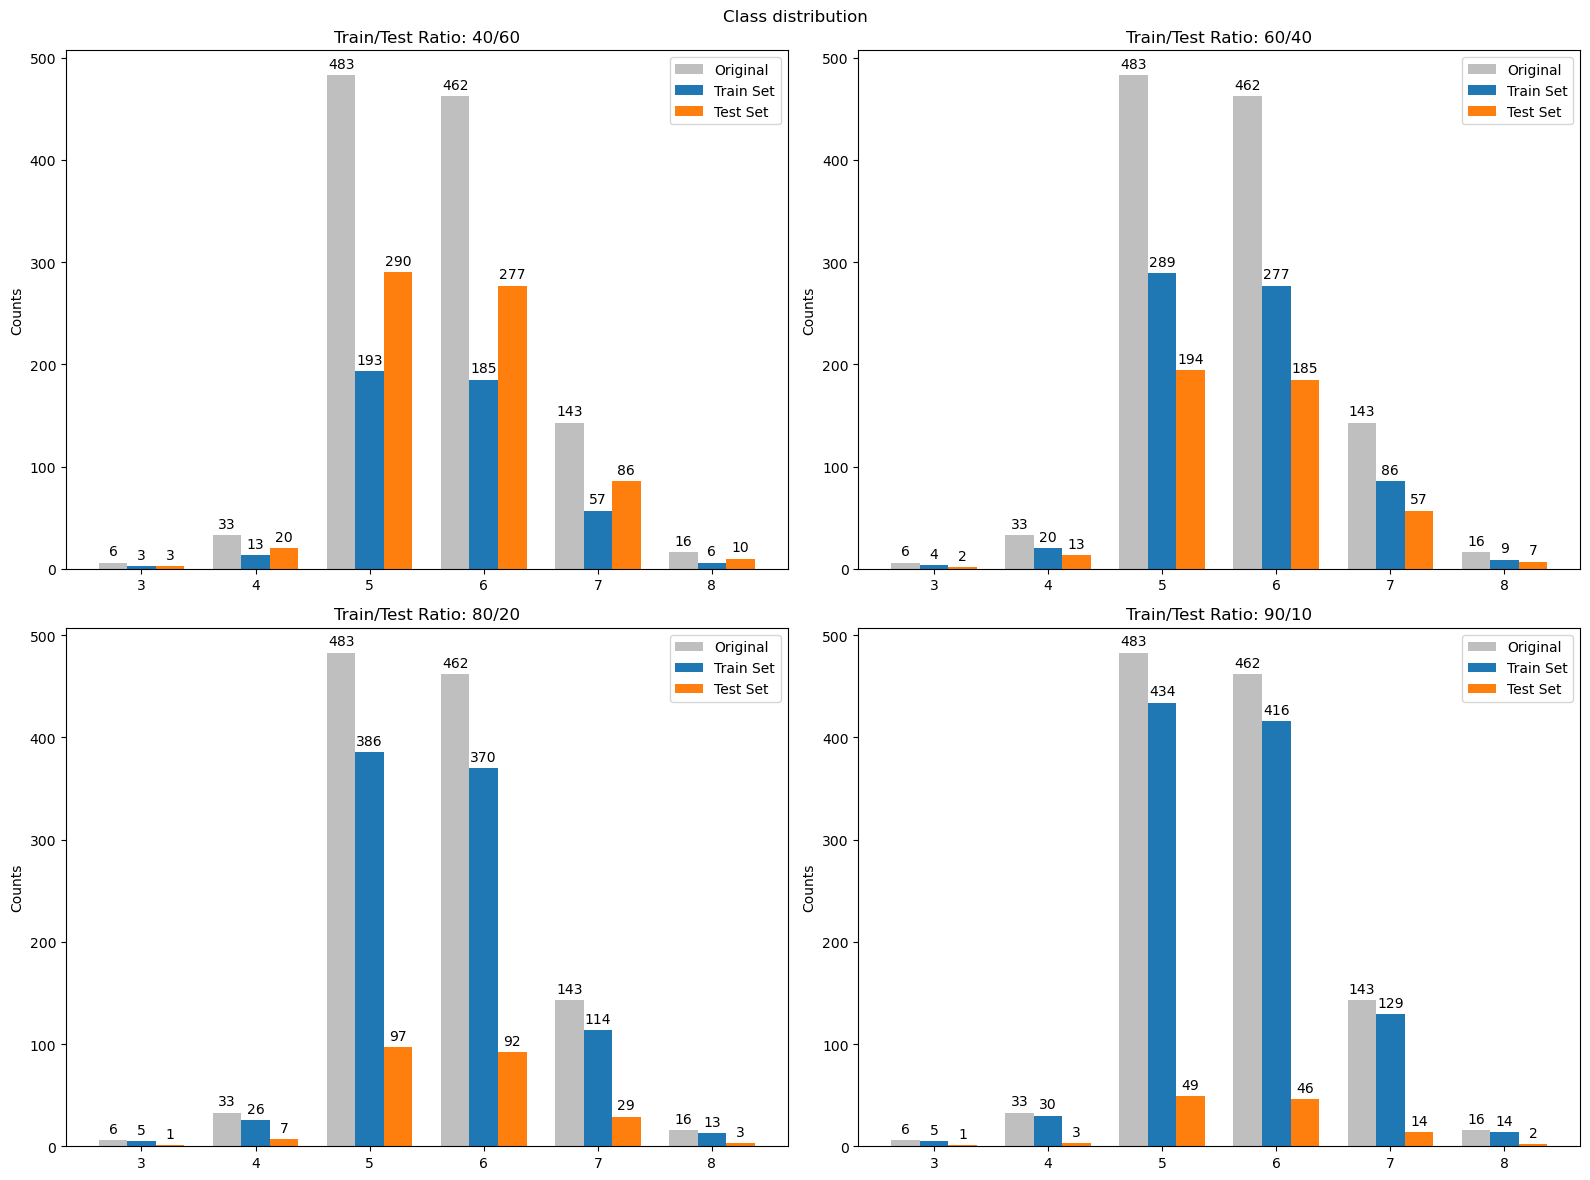

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Class distribution")

for i, ax in enumerate(axes.flat):
    stat = stats[i]
    ratio = stat["ratio"]

    x = np.arange(len(class_names))
    width = 0.25
    
    rects1 = ax.bar(x - width, original_counts, width, label='Original', color='gray', alpha=0.5)
    rects2 = ax.bar(x, stat["train_counts"], width, label='Train Set')
    rects3 = ax.bar(x + width, stat["test_counts"], width, label='Test Set')
    
    ax.set_ylabel('Counts')
    ax.set_title(f'Train/Test Ratio: {ratio}')
    ax.set_xticks(x)
    ax.set_xticklabels(class_names)
    ax.legend()
    
    ax.bar_label(rects1, padding=3)
    ax.bar_label(rects2, padding=3)
    ax.bar_label(rects3, padding=3)

plt.tight_layout()
plt.show()

# Building Decision Tree Classifiers

In [10]:
class_names_str = [str(i) for i in class_names]
class_names_str

['3', '4', '5', '6', '7', '8']

In [11]:
trained_models = {}

def train_draw_dt(ratio, max_depth=3, save_model=True):
    X_curr_train = features['train'][ratio]
    y_curr_train = labels['train'][ratio]
    
    clf = DecisionTreeClassifier(criterion='entropy', 
                                 random_state=33,
                                 max_depth=max_depth,
                                 class_weight='balanced')
    
    clf.fit(X_curr_train, y_curr_train)
    
    
    dot_data = export_graphviz(
        clf,
        out_file=None,              
        feature_names=feature_names, 
        class_names=class_names_str,     
        filled=True,                 
        rounded=True,                
        special_characters=True      
    )
    
    graph = graphviz.Source(dot_data)
    
    display(graph)
    
    filename = f"../img/tree_{ratio.replace('/', '_')}_{max_depth}" 
    graph.render(filename, format='png', cleanup=True)  # Save .png file and clean the .dot file
    print(f"Save file: {filename}.png\n")
    
    # Save model
    if save_model:
        trained_models[ratio] = clf
    else:
        return clf

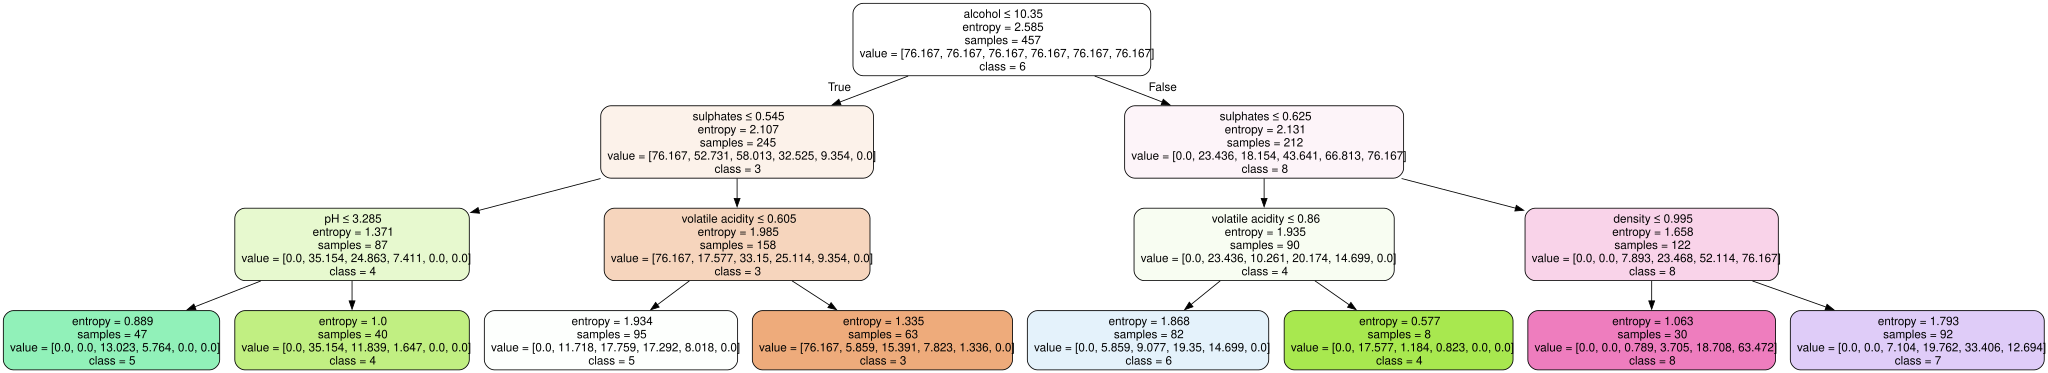

Save file: ../img/tree_40_60_3.png



In [12]:
# Ratio = 40/60
train_draw_dt(ratios_label[0])

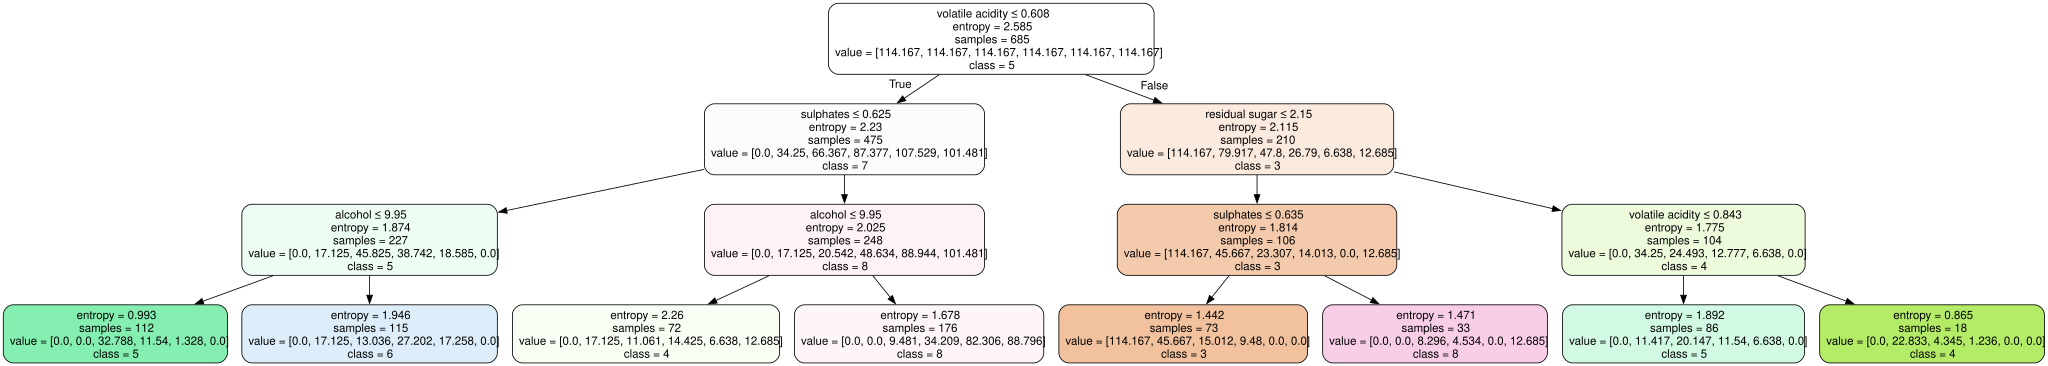

Save file: ../img/tree_60_40_3.png



In [13]:
# Ratio = 60/40
train_draw_dt(ratio=ratios_label[1])

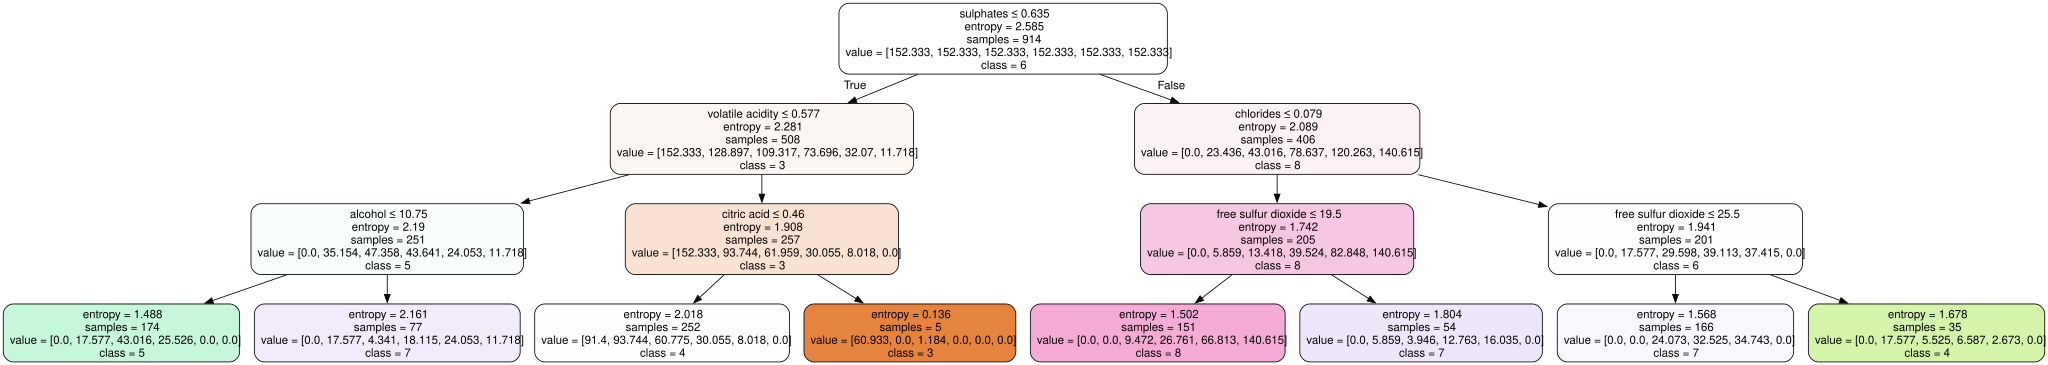

Save file: ../img/tree_80_20_3.png



In [14]:
# Ratio 80/20
train_draw_dt(ratio=ratios_label[2])

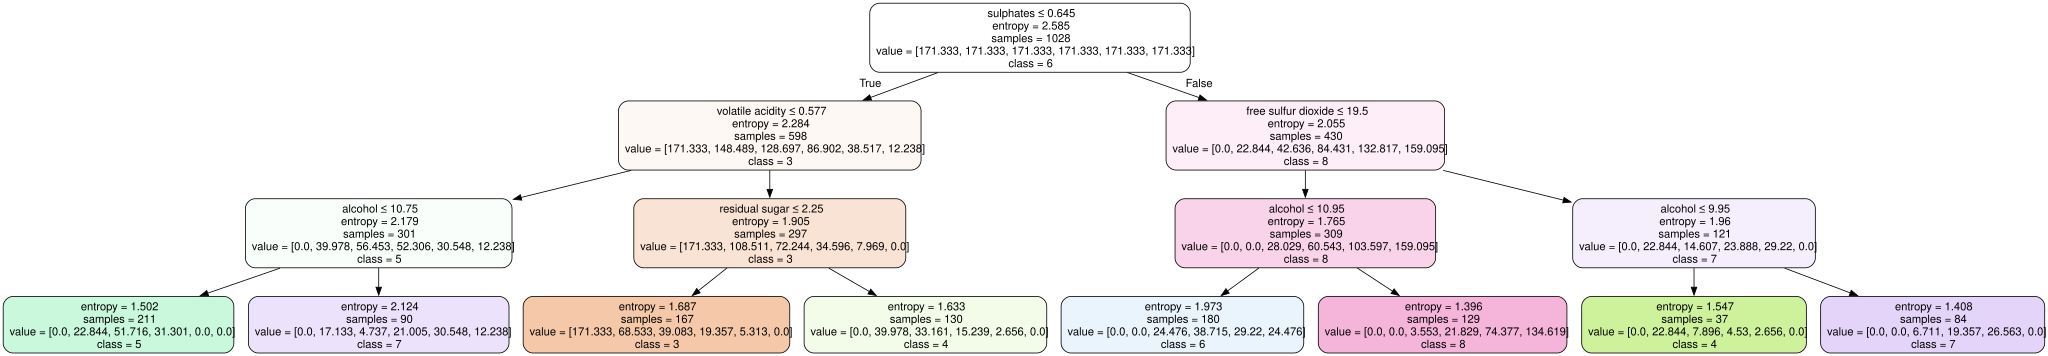

Save file: ../img/tree_90_10_3.png



In [15]:
# Ratio 90/10
train_draw_dt(ratio=ratios_label[3])

# Evaluating Decision Tree

In [24]:
def evaluate_dt(ratio, model, max_depth=3):
    print(f"REPORT FOR RATIO: {ratio}")

    X_test = features['test'][ratio]
    y_test = labels['test'][ratio]
    
    # 2. Dự đoán
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc}")
    
    print("Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    
    # Vẽ hình
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(cmap='Blues', ax=ax, values_format='d')
    ax.set_title(f"Confusion Matrix - Ratio: {ratio}")
    
    fig.savefig(f"../img/confusion_matrix_{ratio.replace('/', '_')}_{max_depth}.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n\n")
    
    return acc

REPORT FOR RATIO: 40/60
Accuracy: 0.35131195335276966
Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.07      0.20      0.10        20
           5       0.54      0.44      0.49       290
           6       0.54      0.23      0.32       277
           7       0.34      0.48      0.40        86
           8       0.05      0.30      0.09        10

    accuracy                           0.35       686
   macro avg       0.26      0.28      0.23       686
weighted avg       0.49      0.35      0.39       686



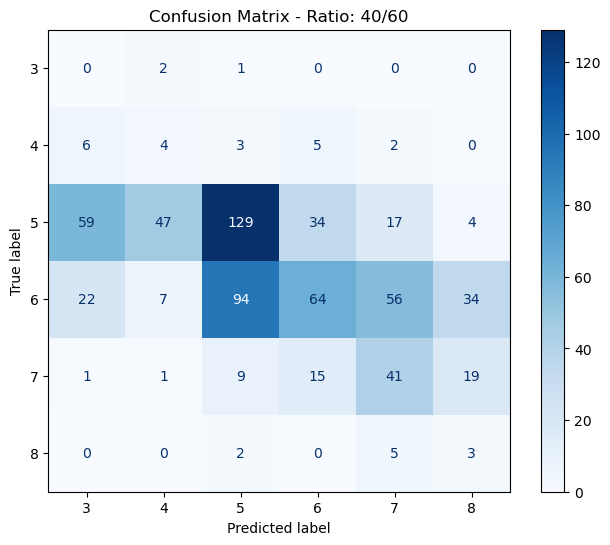




REPORT FOR RATIO: 60/40
Accuracy: 0.24672489082969432
Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.02      0.08      0.03        13
           5       0.58      0.39      0.47       194
           6       0.43      0.16      0.24       185
           7       0.00      0.00      0.00        57
           8       0.04      0.86      0.08         7

    accuracy                           0.25       458
   macro avg       0.18      0.25      0.13       458
weighted avg       0.42      0.25      0.30       458



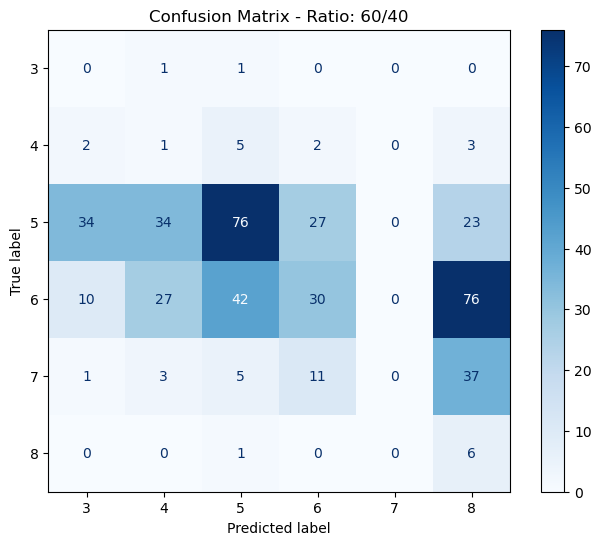




REPORT FOR RATIO: 80/20
Accuracy: 0.2096069868995633
Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.04      0.43      0.08         7
           5       0.65      0.25      0.36        97
           6       0.00      0.00      0.00        92
           7       0.26      0.69      0.38        29
           8       0.03      0.33      0.05         3

    accuracy                           0.21       229
   macro avg       0.16      0.28      0.14       229
weighted avg       0.31      0.21      0.20       229



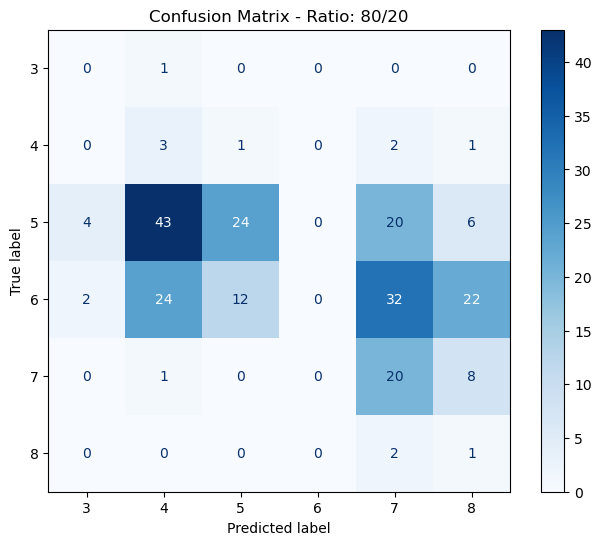




REPORT FOR RATIO: 90/10
Accuracy: 0.2782608695652174
Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.04      0.33      0.07         3
           5       0.62      0.31      0.41        49
           6       0.44      0.17      0.25        46
           7       0.25      0.43      0.32        14
           8       0.29      1.00      0.44         2

    accuracy                           0.28       115
   macro avg       0.27      0.37      0.25       115
weighted avg       0.48      0.28      0.32       115



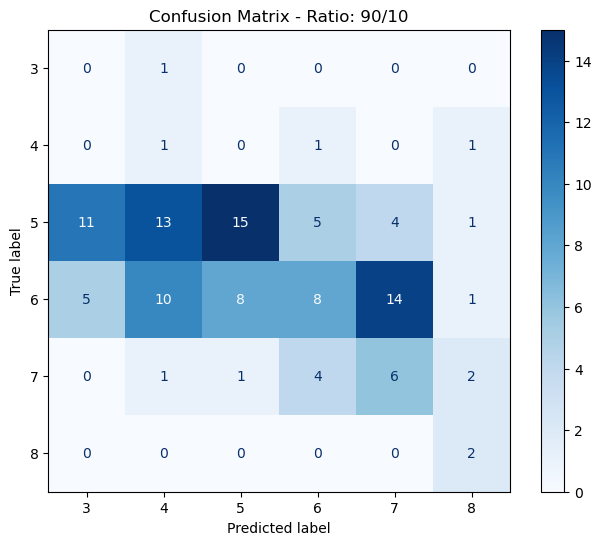

In [26]:
for ratio in ratios_label:
    evaluate_dt(ratio, trained_models[ratio])

**Nhận xét**  
1. **Tỉ lệ dữ liệu huấn luyện**  
Sau khi so sánh accuracy qua các ratio Train/Test khác nhau ta thấy
    - Ratio 40/60 (ít dữ liệu train nhất): Accuracy cao nhất (35%)
    - Ratio 60/40: Accuracy giảm (25%)
    - Ratio 80/20: Accuracy tiếp tục giảm (thấp nhất) (21%)
    - Ratio 90/10: Accuracy hồi phục nhẹ (28%)

$\Rightarrow$ **Insight**: Thông thường, khi dữ liệu train càng nhiều thì accuracy sẽ càng tăng (do học được nhiều pattern hơn). Nhưng ở đây hiệu năng lại giảm dần khi tăng dữ liệu $\rightarrow$ Mô hình đang bị overwhelmed, khi cấu trúc cây quá đơn giản (`max_depth=3`) thì khi tiếp nhận nhiều thông tin phức tạp (từ tập train lớn) sẽ khiến model học sai các quy luật nhiễu thay vì quy luật tổng quát.

2. **Phân tích chi tiết** 

**Tại Ratio 40/60**
- 2 lớp có tỉ lệ chiếm nhiều nhất **Class 5, 6** đều được nhận diện ở mức chấp nhận với Recall lần lượt 0.44 và 0.23
- Mặc dù thấp, nhưng các chỉ số chưa lệch hẳn về phía nào 

**Tại Ratio 60/40**
- Khi tỉ lệ train tăng thì xuất hiện thêm pattern mới **Class 8**, mô hình đột ngộp dự đoán nhiều vào class này.
- Hậu quả là Recall rất cao (0.86) nhưng Precision thì rất thấp (0.04) $\rightarrow$ Dấu hiệu nhánh cây bị rẽ sai hướng do dữ liệu nhiễu trong đầu vào.
- Tại **Class 6**, Recall bắt đầu giảm (0.23 $\rightarrow$ 0.16): class này bắt đầu hi sinh. 

**Tại Ratio 80/20**
- **Class 6** có Recall = 0, mô hình mất khả năng nhận diện class này. Với lượng dữ liệu nhiều, cây quyết định bị nông đã buộc phải loại bỏ hoàn toàn 1 nhóm dữ liệu để tối ưu hoá các nhóm khác, nhưng thất bại (do các feature nhiễu quá nhiều kèm theo là max_depth quá nông)
- Ở đây mô hình lại vướng lỗi tương tự với Ratio trước, nhưng ở đây là đến **Class 7** (Recall = 0.69 nhưng Precision = 0.26)  

**Tại Ratio 90/10**
- Mô hình dự đoán được 1 chút pattern của **Class 6 và 5** nhưng vẫn còn khá kém

$\Rightarrow$ Việc giữ `max_depth=3` trong khi tăng tỉ lệ dữ liệu Train khiến cho mô hình bị overwhelm không tìm được các pattern thật sự dẫn đến việc đoán mò (thể hiện qua Precision cực thấp của **Class 8, 7**) hoặc loại bỏ do không dự đoán được (Recall = 0 ở **Class 6** khi ratio là 80/20)

# The depth and accuracy of a decision tree

MAX DEPTH: None


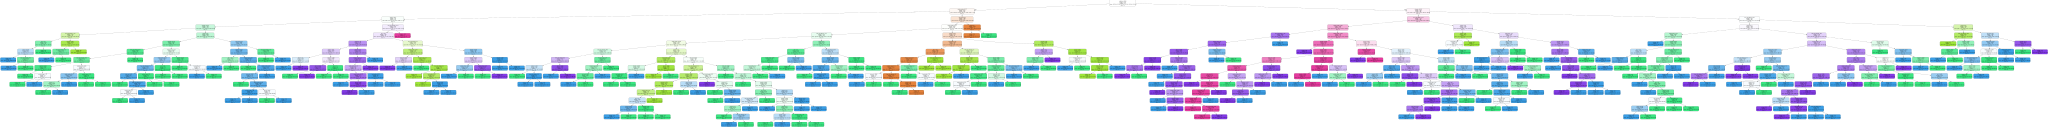

dot: graph is too large for cairo-renderer bitmaps. Scaling by 0.79605 to fit


Save file: ../img/tree_80_20_None.png

REPORT FOR RATIO: 80/20
Accuracy: 0.6157205240174672
Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.64      0.65      0.64        97
           6       0.61      0.62      0.61        92
           7       0.68      0.72      0.70        29
           8       0.00      0.00      0.00         3

    accuracy                           0.62       229
   macro avg       0.32      0.33      0.33       229
weighted avg       0.60      0.62      0.61       229



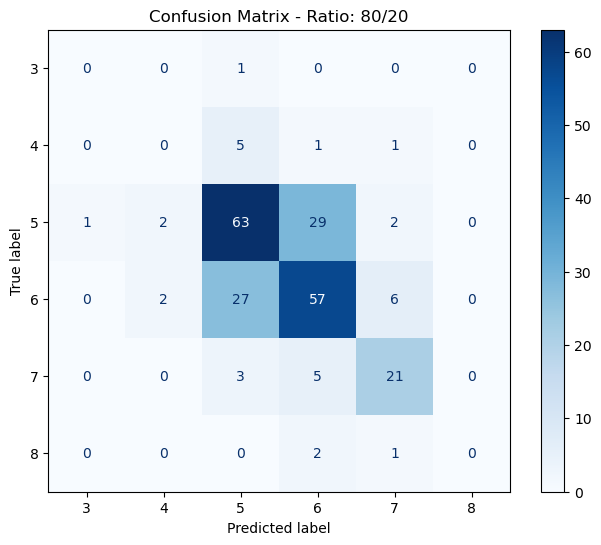




MAX DEPTH: 2


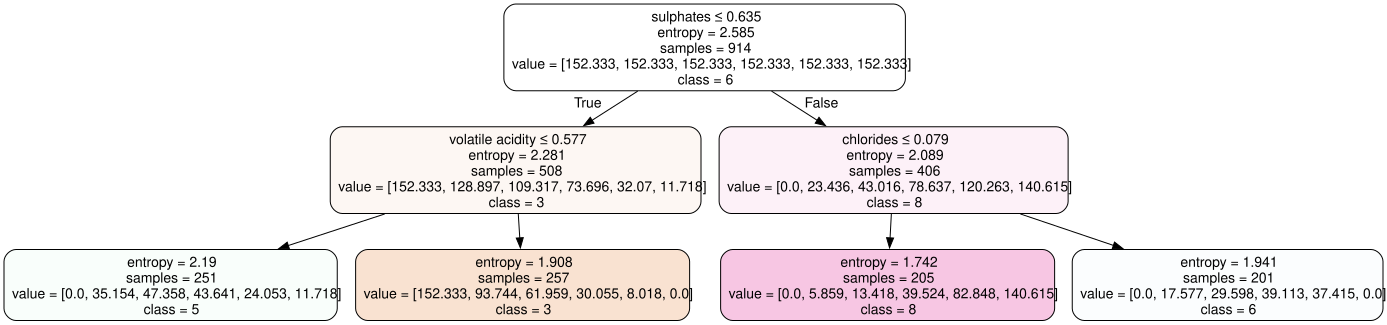

Save file: ../img/tree_80_20_2.png

REPORT FOR RATIO: 80/20
Accuracy: 0.20087336244541484
Classification Report:
              precision    recall  f1-score   support

           3       0.01      1.00      0.03         1
           4       0.00      0.00      0.00         7
           5       0.47      0.28      0.35        97
           6       0.34      0.18      0.24        92
           7       0.00      0.00      0.00        29
           8       0.02      0.33      0.04         3

    accuracy                           0.20       229
   macro avg       0.14      0.30      0.11       229
weighted avg       0.34      0.20      0.25       229



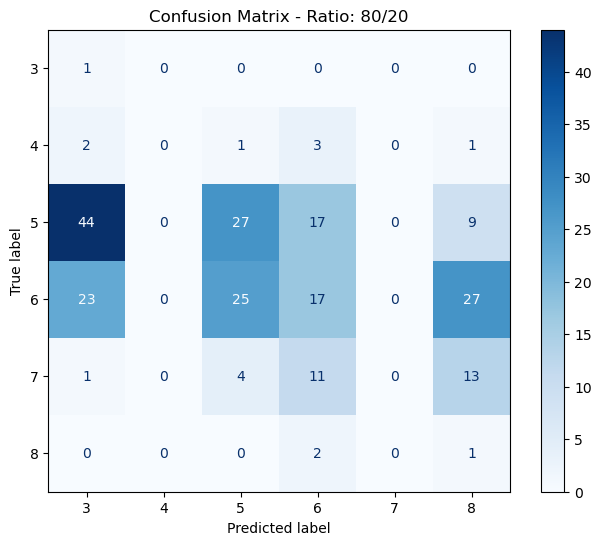




MAX DEPTH: 3


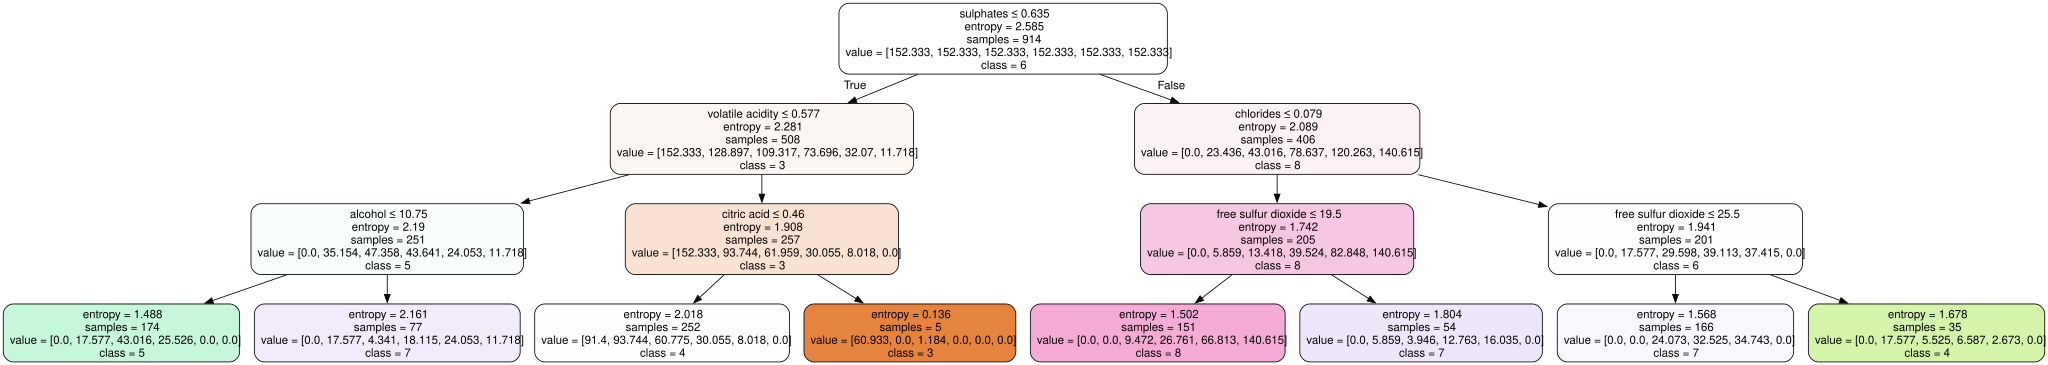

Save file: ../img/tree_80_20_3.png

REPORT FOR RATIO: 80/20
Accuracy: 0.2096069868995633
Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.04      0.43      0.08         7
           5       0.65      0.25      0.36        97
           6       0.00      0.00      0.00        92
           7       0.26      0.69      0.38        29
           8       0.03      0.33      0.05         3

    accuracy                           0.21       229
   macro avg       0.16      0.28      0.14       229
weighted avg       0.31      0.21      0.20       229



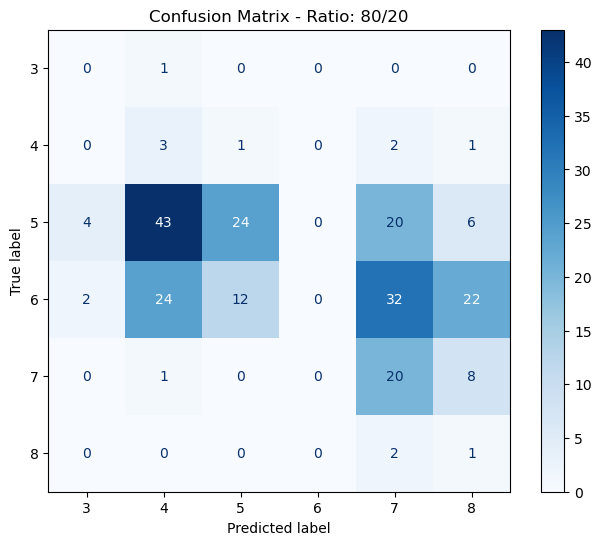




MAX DEPTH: 4


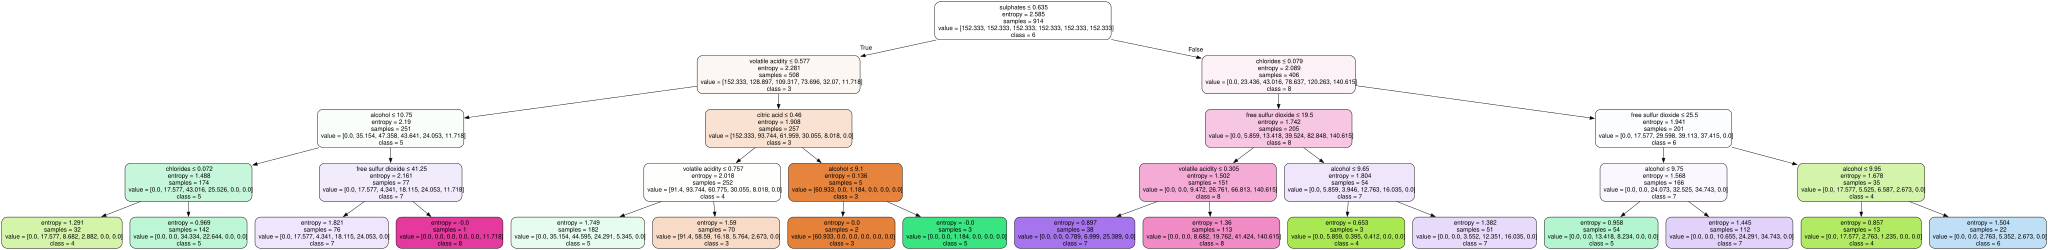

Save file: ../img/tree_80_20_4.png

REPORT FOR RATIO: 80/20
Accuracy: 0.4017467248908297
Classification Report:
              precision    recall  f1-score   support

           3       0.07      1.00      0.12         1
           4       0.09      0.14      0.11         7
           5       0.62      0.66      0.64        97
           6       1.00      0.03      0.06        92
           7       0.34      0.76      0.47        29
           8       0.03      0.33      0.06         3

    accuracy                           0.40       229
   macro avg       0.36      0.49      0.24       229
weighted avg       0.71      0.40      0.36       229



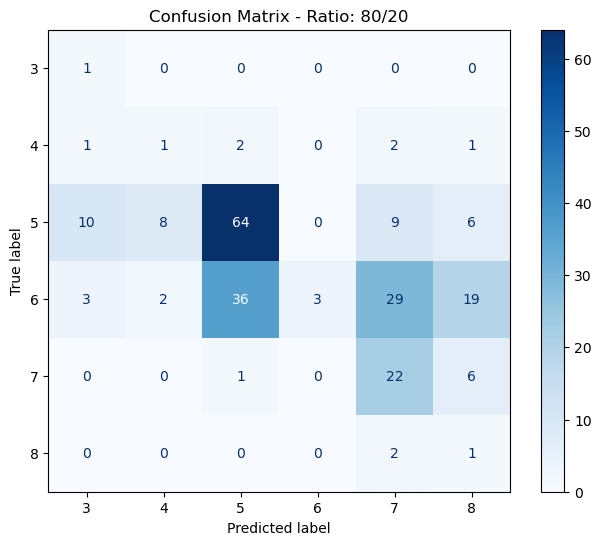




MAX DEPTH: 5


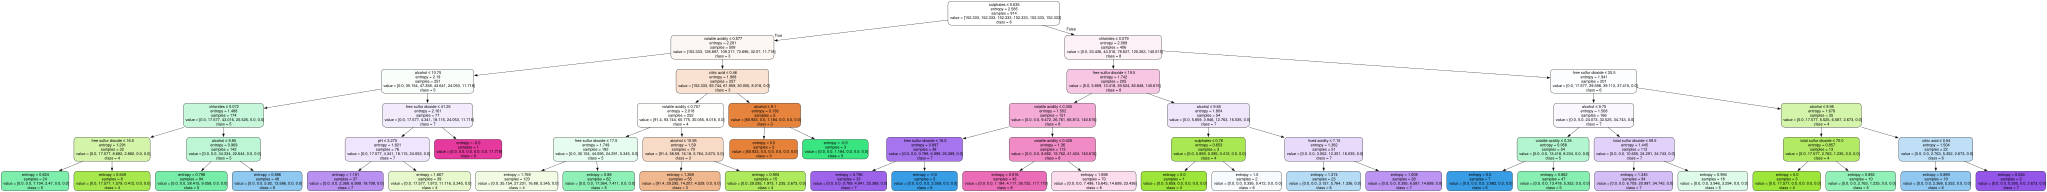

Save file: ../img/tree_80_20_5.png

REPORT FOR RATIO: 80/20
Accuracy: 0.3231441048034934
Classification Report:
              precision    recall  f1-score   support

           3       0.08      1.00      0.15         1
           4       0.02      0.14      0.03         7
           5       0.70      0.43      0.54        97
           6       0.45      0.11      0.18        92
           7       0.44      0.66      0.53        29
           8       0.03      0.33      0.06         3

    accuracy                           0.32       229
   macro avg       0.29      0.45      0.25       229
weighted avg       0.54      0.32      0.37       229



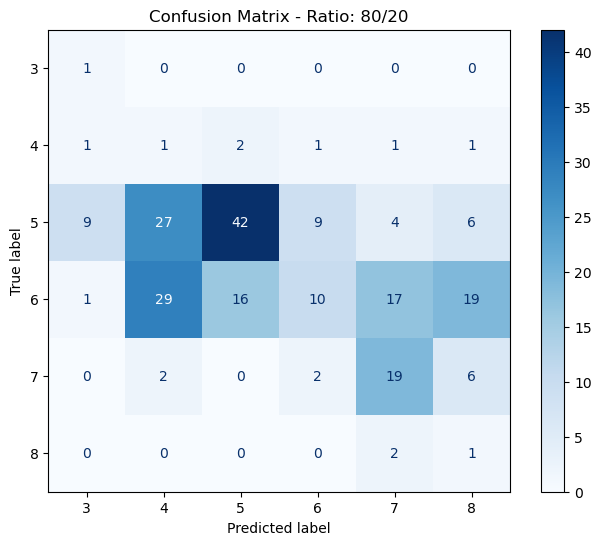




MAX DEPTH: 6


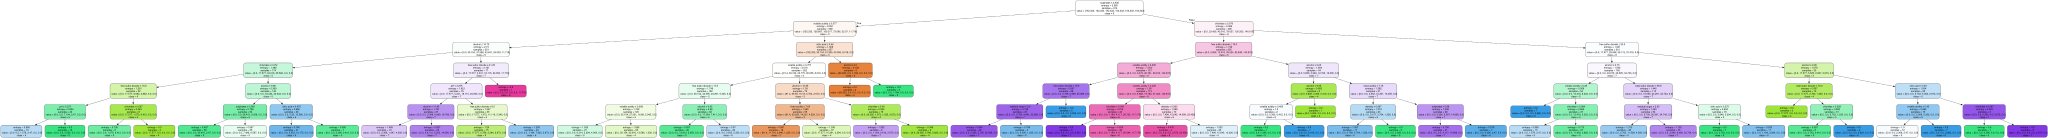

Save file: ../img/tree_80_20_6.png

REPORT FOR RATIO: 80/20
Accuracy: 0.4497816593886463
Classification Report:
              precision    recall  f1-score   support

           3       0.17      1.00      0.29         1
           4       0.02      0.14      0.04         7
           5       0.69      0.43      0.53        97
           6       0.59      0.43      0.50        92
           7       0.47      0.62      0.54        29
           8       0.11      0.33      0.17         3

    accuracy                           0.45       229
   macro avg       0.34      0.49      0.34       229
weighted avg       0.59      0.45      0.50       229



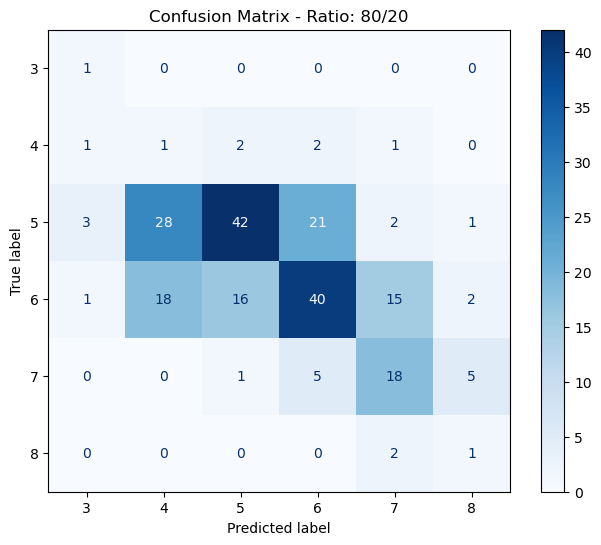




MAX DEPTH: 7


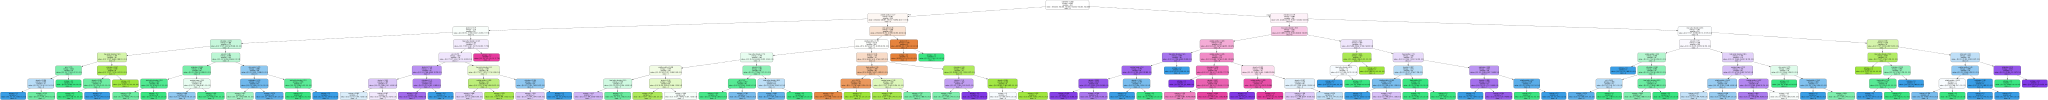

Save file: ../img/tree_80_20_7.png

REPORT FOR RATIO: 80/20
Accuracy: 0.5109170305676856
Classification Report:
              precision    recall  f1-score   support

           3       0.17      1.00      0.29         1
           4       0.00      0.00      0.00         7
           5       0.64      0.60      0.62        97
           6       0.61      0.41      0.49        92
           7       0.39      0.66      0.49        29
           8       0.12      0.33      0.18         3

    accuracy                           0.51       229
   macro avg       0.32      0.50      0.34       229
weighted avg       0.57      0.51      0.52       229



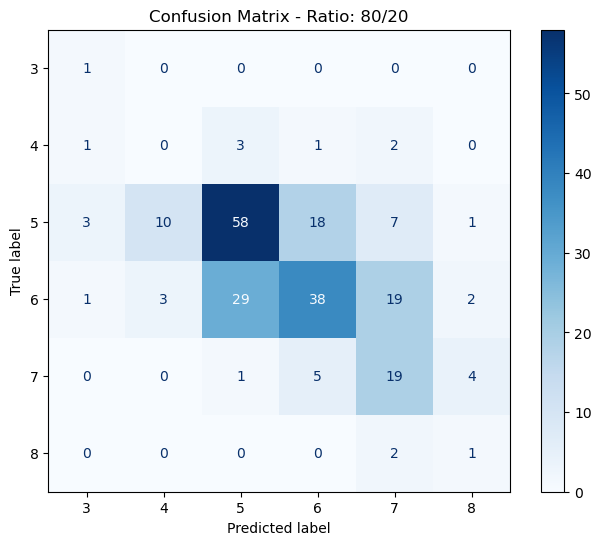

In [27]:
max_depth_list = [None, 2, 3, 4, 5, 6, 7]

accuracy = {}

for depth in max_depth_list:
    print(f"MAX DEPTH: {depth}")
    model = train_draw_dt(ratio='80/20', max_depth=depth, save_model=False)
    
    accuracy[depth] = evaluate_dt(ratio='80/20', model=model, max_depth=depth)

## Visualize Accuracy and Max Depth

In [28]:
acc_none = accuracy.pop(None)

In [29]:
accuracy

{2: 0.20087336244541484,
 3: 0.2096069868995633,
 4: 0.4017467248908297,
 5: 0.3231441048034934,
 6: 0.4497816593886463,
 7: 0.5109170305676856}

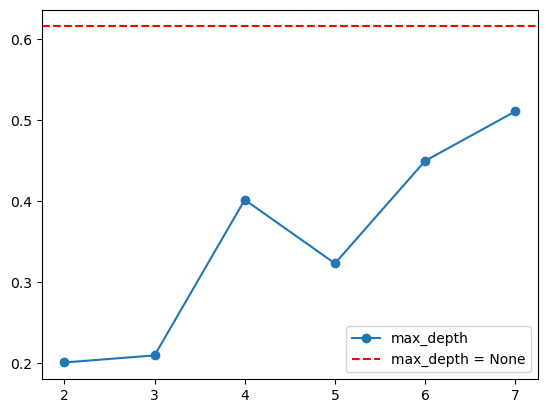

In [30]:
lists = sorted(accuracy.items()) 
x, y = zip(*lists)

plt.plot(x, y, marker='o', label='max_depth')
plt.axhline(y=acc_none, color='r', linestyle='--', label='max_depth = None')
plt.legend()
plt.show()

**Insight**
- Theo line chart cho thấy có mối tương quan dương giữa `max_depth` và `accuracy` (khi `max_depth` càng tăng thì `accuracy` có xu hướng tăng theo)

- Tại `max_depth` thấp (2, 3), mô hình có hiện tượng **Underfitting** với `accuracy ~20%` $\rightarrow$ Chứng tỏ ở độ sâu nông thì mô hình chưa học được pattern của dữ liệu để dự đoán chính xác.

- Tuy nhiên, khi `max_depth=5` có sự giảm bất thường (từ `0,4` $\rightarrow$ `0.32`) sau đó lại tăng ở `max_depth=6` $\rightarrow$ Đây chứng minh cho tính chất Greedy và không ổn định của cây quyết định. Ở `max_depth=5` có thể mô hình đã chọn một đặc trưng nhiễu để chia nhánh dẫn đến việc sai số tăng. Nhưng khi ở `max_depth=6` mô hình có đủ không gian hơn để dự đoán chính xác cho các nhánh con tiếp theo.

- So với Baseline, giá trị cao trong thử nghiệm (`max_depth=7`) là 0.51 vẫn thấp hơn đáng kể so với trường hợp không giới hạn độ sâu (`None`) $\rightarrow$ Điểm tối ưu thực sự của mô hình này nằm ở `max_depth>7`.